Wind conditions at the Turn Point spill locations in the Salish Sea

- Surface winds, hourly atmospheric field values from the Environment Canada High Resolution Deterministic Prediction System (HRDPS) atmospheric forcing model. Data from SalishSeaCast ERDDAP (https://salishsea.eos.ubc.ca/erddap/index.html)
- Fraser River Discharge (m^3), from SalishSeaCast.

In [1]:
import sys
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from cartopy import crs, feature
from pathlib import Path
from datetime import datetime, date
from IPython.display import Image
from mpl_toolkits.axes_grid1 import make_axes_locatable

from salishsea_tools import places, wind_tools

In [2]:
# Data Paths
current_path = Path('/ocean/rlovindeer/Atlantis/Physics/Raw_Transport_Data/')
wind_path = Path('/ocean/rlovindeer/Atlantis/Physics/Wind/')
wind_speed_path = Path('/results/forcing/atmospheric/GEM2.5/operational/') #file format ops_y2019m07d07.nc vars(u_wind, v_wind)
sea_grid = Path('/ocean/rlovindeer/Atlantis/Physics/Grids/ubcSSnBathymetryV17-02_a29d_efc9_4047.nc')
air_grid = Path('/ocean/rlovindeer/Atlantis/Physics/Grids/ubcSSaAtmosphereGridV1_0f03_6268_df4b.nc')
river_path = Path('/ocean/rlovindeer/MOAD/analysis-raisha/notebooks/contaminant-dispersal/results/Rivers')

In [3]:
mpri2_winds = ['2019-01-20_Wind_variables.nc','2019-04-12_Wind_variables.nc','2019-07-03_Wind_variables.nc','2019-10-20_Wind_variables.nc',
    '2020-01-24_Wind_variables.nc','2020-04-11_Wind_variables.nc','2020-07-05_Wind_variables.nc','2020-10-20_Wind_variables.nc',
]

## Fraser river discharge into the Salish Sea

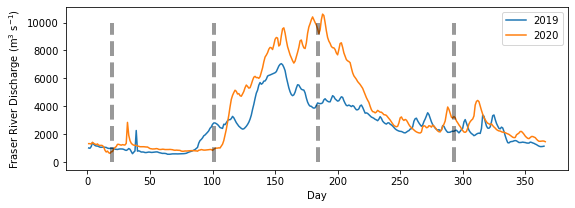

In [135]:
rivers = sorted([p for p in river_path.glob('*_2019_2020.csv')])
for path in rivers:
    discharge = pd.read_csv(path)
    discharge.plot('Day', figsize=(9, 3), ylabel='Fraser River Discharge (m$^{3}$ s$^{-1}$)')
plt.plot([20,20],[0,10000],'k--',linewidth=4, alpha=0.4,label='winter')
plt.plot([101,101],[0,10000],'k--',linewidth=4, alpha=0.4,label='spring')
plt.plot([184,184],[0,10000],'k--',linewidth=4, alpha=0.4,label='summer')
plt.plot([293,293],[0,10000],'k--',linewidth=4, alpha=0.4,label='fall')
plt.savefig("Fraser_discharge_2019-2020.png", dpi=300, bbox_inches='tight')
    

## Surface winds at nearest location
Turn Point winds plotted at Sand Heads and Victoria

In [5]:
def plot_wind(wind_paths, place):
    
    yx = places.PLACES[place]['wind grid ji']
    
    winds = sorted([p for p in wind_path.glob(wind_paths)])
    plt.figure(figsize = (15,3))
    for path in currents:
        wind_data = xr.open_dataset(path)
        wind_speed, wind_dir = wind_tools.wind_speed_dir(wind_data.u_wind[:,yx[0],yx[1]], wind_data.v_wind[:,yx[0],yx[1]])
        #plt.plot(wind_data.time, wind_speed, 'k')
        plt.scatter(wind_data.time, wind_dir, c=wind_speed, cmap='viridis')
        #plt.colorbar(label='Wind speed (m/s)')

In [6]:
def plot_wind_at_location(wind_paths, place):
    yx = places.PLACES[place]['wind grid ji']
    winds = sorted([p for p in wind_path.glob(wind_paths)])
    plt.figure(figsize = (15,3))
    for path in winds:
        wind_data = xr.open_dataset(path)
        wind_speed, wind_dir = wind_tools.wind_speed_dir(wind_data.u_wind[:,yx[0],yx[1]], wind_data.v_wind[:,yx[0],yx[1]])
        u = wind_data.u_wind[:,yx[0],yx[1]]   # east-west component
        v = wind_data.v_wind[:,yx[0],yx[1]]   # north-south component
        #plt.scatter(u,v, c=wind_speed, cmap='viridis')
        plt.bar(wind_data.time, u, color='orange', label='E/W wind component')
        plt.bar(wind_data.time, v, color='blue', label='N/S wind component')
        #plt.bar(wind_data.time, wind_speed, color='k', label='Wind speed (m/s)')
    plt.legend(['E/W wind component','N/S wind component'])
    plt.ylabel('Wind speed (m/s)')

In [52]:
def plot_wind_at_location2(wind_paths, place):
    yx = places.PLACES[place]['wind grid ji']
    winds = sorted([p for p in wind_path.glob(wind_paths)])
    for path in winds:
        wind_data = xr.open_dataset(path)
        wind_speed, wind_dir = wind_tools.wind_speed_dir(wind_data.u_wind[:,yx[0],yx[1]], wind_data.v_wind[:,yx[0],yx[1]])
        u = wind_data.u_wind[:,yx[0],yx[1]]   # east-west component
        v = wind_data.v_wind[:,yx[0],yx[1]]   # north-south component
        plt.bar(wind_data.time, u, color='orange', label='E/W wind component')
        plt.bar(wind_data.time, v, color='blue', label='N/S wind component')
    plt.legend(['E/W wind component','N/S wind component'], ncol=2, loc='upper center')
    plt.ylabel('Wind speed (m/s)')
    #plt.savefig("winds_"+place+"_"+str(np.random.randint(0, 100))+".png", dpi=300, bbox_inches='tight')

In [8]:
def plot_wind_map(wind_paths):
    #yx = places.PLACES[place]['wind grid ji']
    winds = sorted([p for p in wind_path.glob(wind_paths)])
    plt.figure(figsize = (5,5))
    for path in winds:
        wind_data = xr.open_dataset(path)
        wind_speed, wind_dir = wind_tools.wind_speed_dir(wind_data.u_wind[:,:,:], wind_data.v_wind[:,:,:])
        theta = np.deg2rad(wind_dir.mean(axis=0))
        u = wind_speed.mean(axis=0) * np.cos(theta)   # east-west component
        v = wind_speed.mean(axis=0) * np.sin(theta)   # north-south component
        grid = xr.open_dataset(air_grid)
        lon = grid.longitude.values - 360
        lat = grid.latitude.values
        plt.quiver(lon,lat,u,v, wind_speed.mean(axis=0), scale=100, cmap='viridis')
        plt.colorbar(label='Wind speed (m/s)')
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        plt.xlim(-125, -122.5)
        plt.ylim(48, 49)
        plt.show()

In [9]:
def plot_wind_map2(wind_paths):
    #yx = places.PLACES[place]['wind grid ji']
    winds = sorted([p for p in wind_path.glob(wind_paths)])
    date_label = wind_paths.split(sep = '_')[0]
    
    for path in winds:
        wind_data = xr.open_dataset(path)
        wind_speed, wind_dir = wind_tools.wind_speed_dir(wind_data.u_wind[:,:,:], wind_data.v_wind[:,:,:])
        theta = np.deg2rad(wind_dir.mean(axis=0))
        u = wind_speed.mean(axis=0) * np.cos(theta)   # east-west component
        v = wind_speed.mean(axis=0) * np.sin(theta)   # north-south component
        grid = xr.open_dataset(air_grid)
        lon = grid.longitude.values - 360
        lat = grid.latitude.values

        step = 5 # reduce arrow density
        fig = plt.figure(figsize=(8,3))
        ax = plt.axes(projection=crs.PlateCarree())
        ax.set_extent([-124, -122.5, 48, 49])
        ax.coastlines()
        q = ax.quiver(lon[::step],lat[::step],u[::step],v[::step],wind_speed.mean(axis=0)[::step],
            cmap='viridis',transform=crs.PlateCarree(),scale=90)
        cbar = plt.colorbar(q, ax=ax) #pad=0.03, shrink=0.8
        cbar.set_label('Wind speed (m/s)')
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        fig.savefig("wind_map_"+date_label+".png", dpi=300, bbox_inches='tight')
        plt.show()

In [10]:
grid = xr.open_dataset(air_grid)
grid

<xarray.Dataset>
Dimensions:    (gridY: 266, gridX: 256)
Coordinates:
  * gridY      (gridY) float64 0.0 2.5e+03 5e+03 ... 6.575e+05 6.6e+05 6.625e+05
  * gridX      (gridX) float64 0.0 2.5e+03 5e+03 ... 6.35e+05 6.375e+05
Data variables:
    longitude  (gridY, gridX) float32 ...
    latitude   (gridY, gridX) float32 ...
Attributes: (12/22)
    acknowledgement:           Environment Canada, MEOPAR, ONC, Compute Canada
    cdm_data_type:             Grid
    Conventions:               CF-1.6, COARDS, ACDD-1.3
    coverage_content_type:     modelResult
    creator_email:             sallen@eos.ubc.ca
    creator_name:              Salish Sea MEOPAR Project Contributors
    ...                        ...
    NCO:                       4.4.2
    project:                   Salish Sea MEOPAR NEMO Model
    sourceUrl:                 (local files)
    standard_name_vocabulary:  CF Standard Name Table v29
    summary:                   HRDPS, Salish Sea, Atmospheric Forcing Grid, G...
    title:                     HRDPS, Salish Sea, Atmospheric Forcing Grid, G...

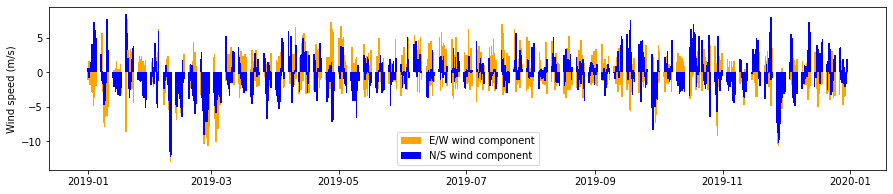

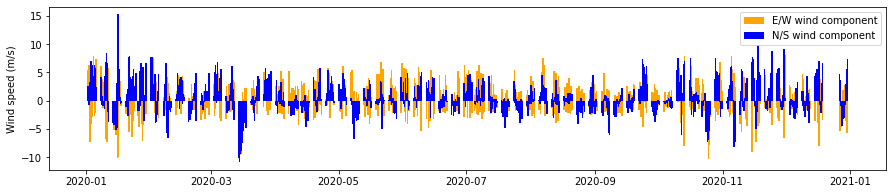

In [11]:
for year in [2019, 2020]:
    plot_wind_at_location(str(year)+'*_Wind_variables.nc', 'Swartz Bay')

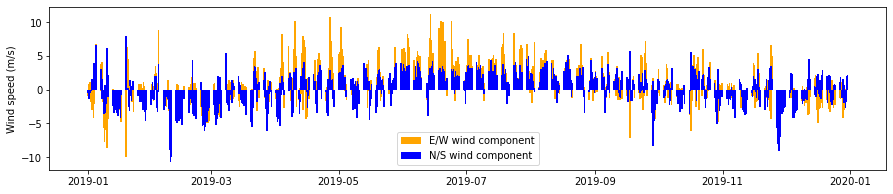

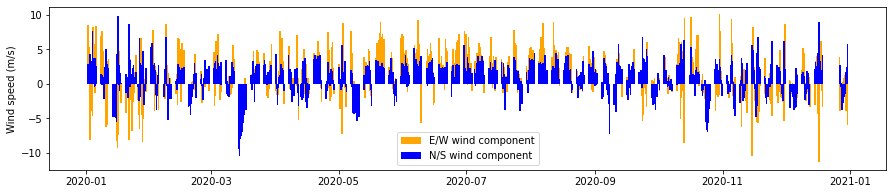

In [12]:
for year in [2019, 2020]:
    plot_wind_at_location(str(year)+'*_Wind_variables.nc', 'Victoria')

Winter

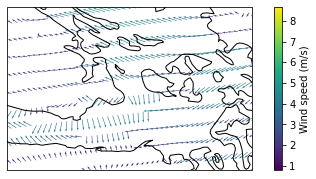

In [13]:
plot_wind_map2('2019-01-20_Wind_variables.nc')

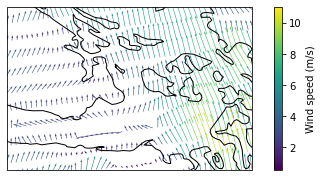

In [14]:
plot_wind_map2('2020-01-24_Wind_variables.nc')

Spring

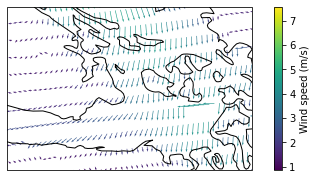

In [15]:
plot_wind_map2('2019-04-12_Wind_variables.nc')

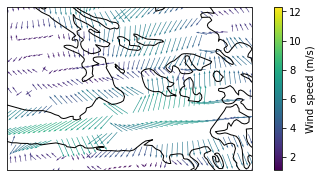

In [16]:
plot_wind_map2('2020-04-11_Wind_variables.nc')

Summer

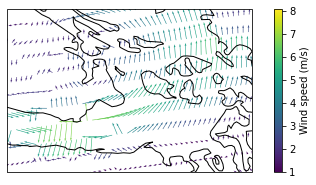

In [17]:
plot_wind_map2('2019-07-03_Wind_variables.nc')

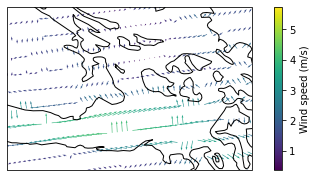

In [18]:
plot_wind_map2('2020-07-05_Wind_variables.nc')

Fall

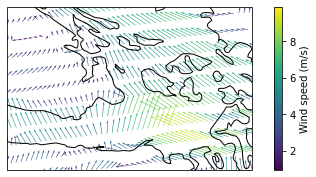

In [19]:
plot_wind_map2('2019-10-20_Wind_variables.nc')

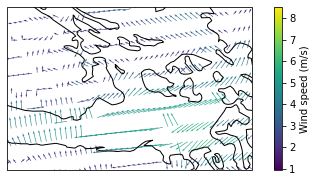

In [20]:
plot_wind_map2('2020-10-20_Wind_variables.nc')

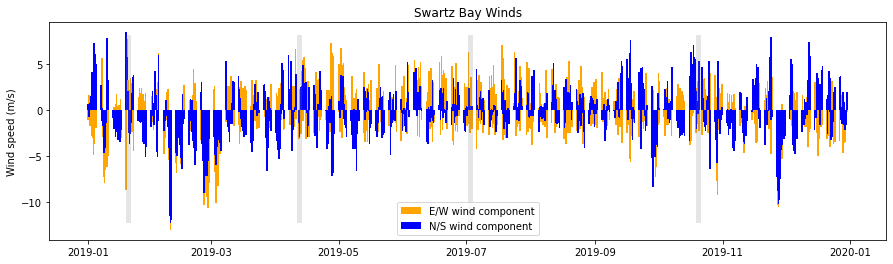

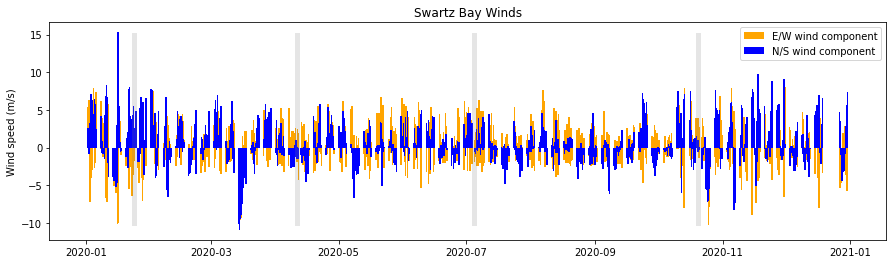

In [21]:
yx = places.PLACES['Swartz Bay']['wind grid ji']
dates_2019 = [datetime(2019,1,20),datetime(2019,4,12),datetime(2019,7,3),datetime(2019,10,20)]
dates_2020 = [datetime(2020,1,24),datetime(2020,4,11),datetime(2020,7,5),datetime(2020,10,20)]

winds = sorted([p for p in wind_path.glob('2019*_Wind_variables.nc')])
plt.figure(figsize = (15,4))
for file in winds:
    wind_data = xr.open_dataset(file)
    wind_speed, wind_dir = wind_tools.wind_speed_dir(wind_data.u_wind[:,yx[0],yx[1]], wind_data.v_wind[:,yx[0],yx[1]])
    theta = np.deg2rad(wind_dir.mean(axis=0))
    u = wind_data.u_wind[:,yx[0],yx[1]]   # east-west component
    v = wind_data.v_wind[:,yx[0],yx[1]]   # north-south component
    plt.bar(wind_data.time, u, color='orange', label='E/W wind component')
    plt.bar(wind_data.time, v, color='blue', label='N/S wind component')
plt.legend(['E/W wind component','N/S wind component'])
for date in dates_2019:
    plt.plot([date,date], [8, -12], color='grey', linewidth = 5, alpha=0.2)
plt.ylabel('Wind speed (m/s)')
plt.title('Swartz Bay Winds')
plt.show;
plt.savefig("winds_2019.png", dpi=300, bbox_inches='tight')

winds = sorted([p for p in wind_path.glob('2020*_Wind_variables.nc')])
plt.figure(figsize = (15,4))
for file in winds:
    wind_data = xr.open_dataset(file)
    wind_speed, wind_dir = wind_tools.wind_speed_dir(wind_data.u_wind[:,yx[0],yx[1]], wind_data.v_wind[:,yx[0],yx[1]])
    theta = np.deg2rad(wind_dir.mean(axis=0))
    u = wind_data.u_wind[:,yx[0],yx[1]]   # east-west component
    v = wind_data.v_wind[:,yx[0],yx[1]]   # north-south component
    plt.bar(wind_data.time, u, color='orange', label='E/W wind component')
    plt.bar(wind_data.time, v, color='blue', label='N/S wind component')
plt.legend(['E/W wind component','N/S wind component'])
for date in dates_2020:
    plt.plot([date,date], [15, -10], color='grey',linewidth = 5, alpha=0.2)
plt.ylabel('Wind speed (m/s)')
plt.title('Swartz Bay Winds')
plt.show;
plt.savefig("winds_2020.png", dpi=300, bbox_inches='tight')

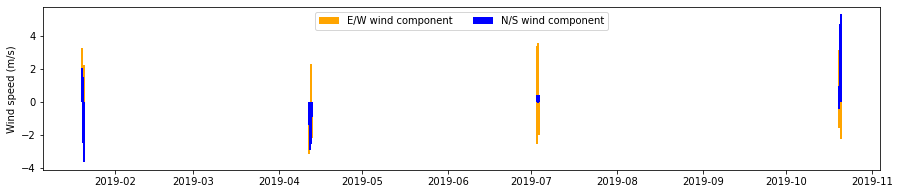

In [64]:
fig = plt.subplots(figsize=(15, 3))
for file in mpri2_winds[0:4]:
    plot_wind_at_location2(file, 'Swartz Bay')

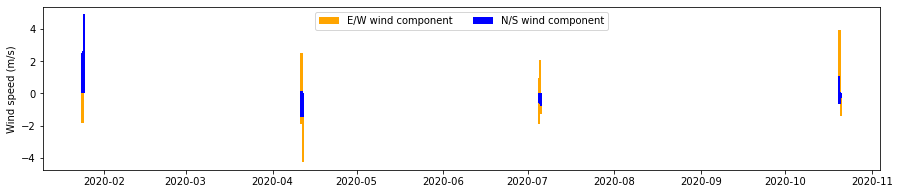

In [66]:
fig = plt.subplots(figsize=(15, 3))
for file in mpri2_winds[4:8]:
    plot_wind_at_location2(file, 'Swartz Bay')

2019-01-20_Wind_variables.nc
2019-04-12_Wind_variables.nc
2019-07-03_Wind_variables.nc
2019-10-20_Wind_variables.nc
2020-01-24_Wind_variables.nc
2020-04-11_Wind_variables.nc
2020-07-05_Wind_variables.nc
2020-10-20_Wind_variables.nc


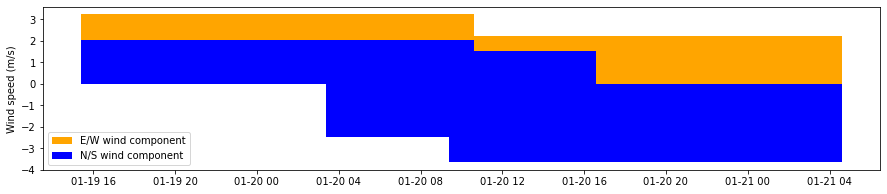

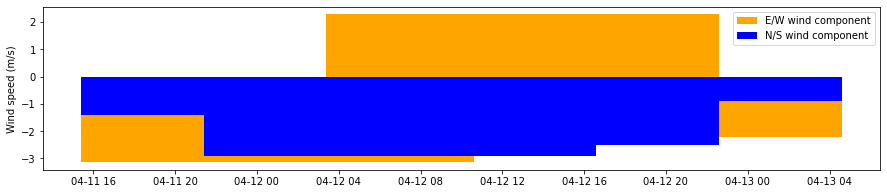

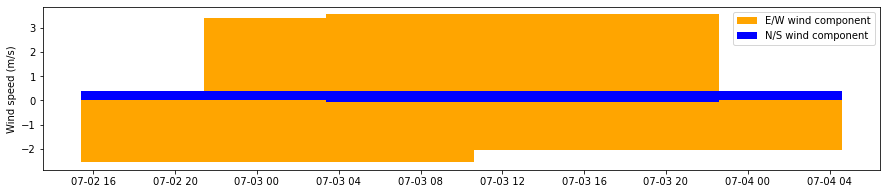

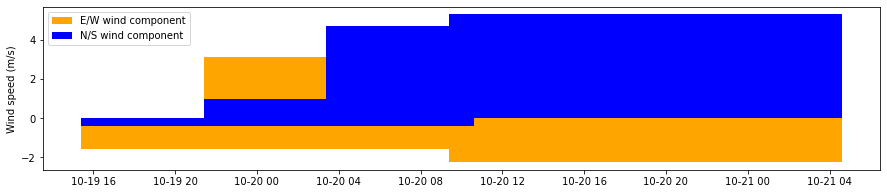

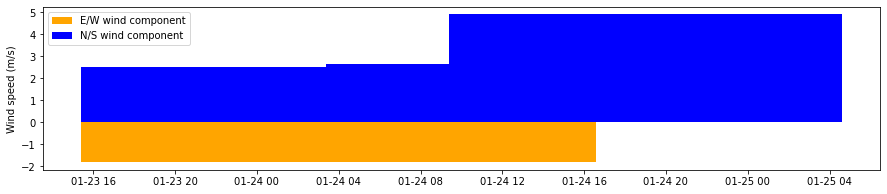

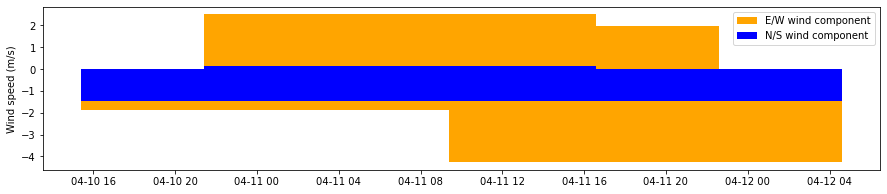

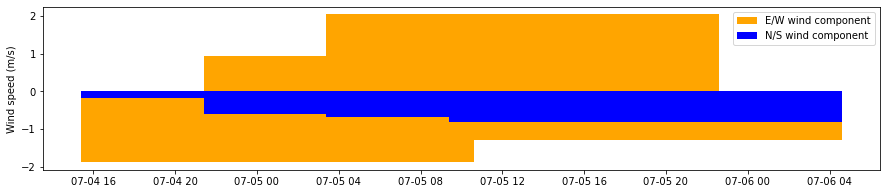

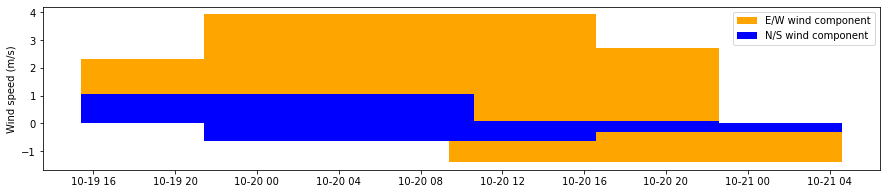

In [69]:
for file in mpri2_winds:
    plot_wind_at_location(file, 'Swartz Bay')

## Currents

Spring

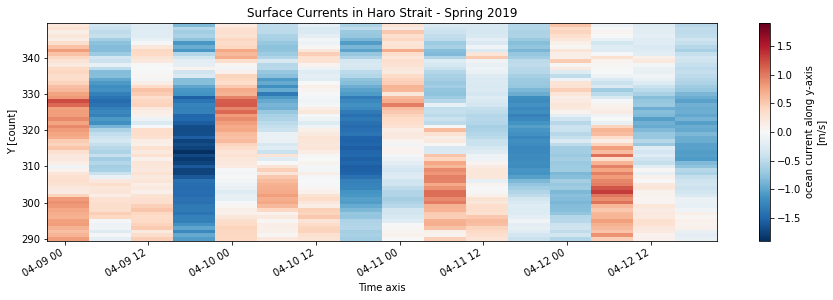

In [111]:
currents = sorted([p for p in current_path.glob('2019-04-09_VRaw_variables.nc')])
for file in currents:
    plt.figure(figsize = (15,4))
    current_data = xr.open_dataset(file)
    current_data.vVelocity[:, 0, 290:350, 238].plot(x="time")
    plt.title('Surface Currents in Haro Strait - Spring 2019')

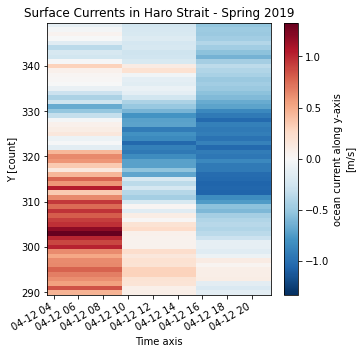

In [124]:
currents = sorted([p for p in current_path.glob('2019-04-09_VRaw_variables.nc')])
date = datetime(2019,4,12)
for file in currents:
    plt.figure(figsize = (5,5))
    current_data = xr.open_dataset(file)
    current_data.vVelocity[13:17, 0, 290:350, 238].plot(x="time")
    #plt.plot([date,date], [1.5, -1.5], color='grey',linewidth = 5, alpha=0.2)
    plt.title('Surface Currents in Haro Strait - Spring 2019')
    plt.savefig("currents_2019_spring.png", dpi=300, bbox_inches='tight')

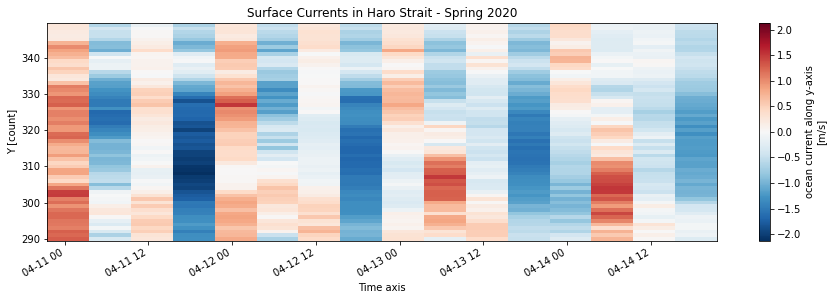

In [97]:
currents = sorted([p for p in current_path.glob('2020-04-11_VRaw_variables.nc')])
for file in currents:
    plt.figure(figsize = (15,4))
    current_data = xr.open_dataset(file)
    current_data.vVelocity[:, 0, 290:350, 238].plot(x="time")
    plt.title('Surface Currents in Haro Strait - Spring 2020')

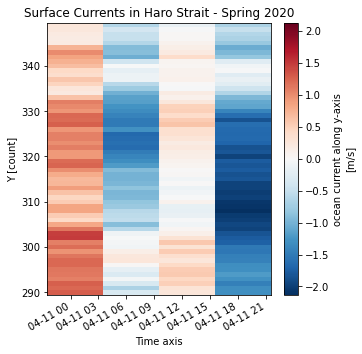

In [125]:
currents = sorted([p for p in current_path.glob('2020-04-11_VRaw_variables.nc')])
for file in currents:
    plt.figure(figsize = (5,5))
    current_data = xr.open_dataset(file)
    current_data.vVelocity[0:4, 0, 290:350, 238].plot(x="time")
    plt.title('Surface Currents in Haro Strait - Spring 2020')
    plt.savefig("currents_2020_spring.png", dpi=300, bbox_inches='tight')

Summer

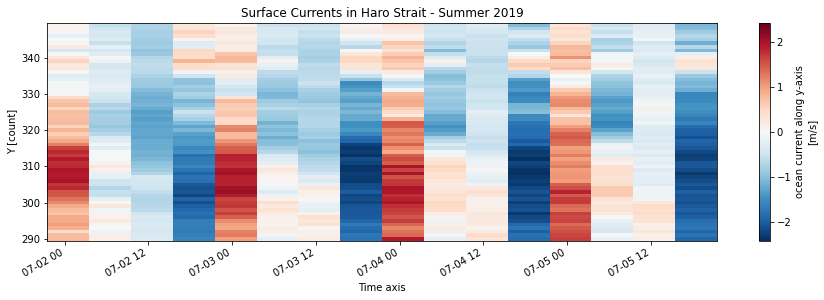

In [126]:
currents = sorted([p for p in current_path.glob('2019-07-02_VRaw_variables.nc')])
for file in currents:
    plt.figure(figsize = (15,4))
    current_data = xr.open_dataset(file)
    current_data.vVelocity[:, 0, 290:350, 238].plot(x="time")
    plt.title('Surface Currents in Haro Strait - Summer 2019')

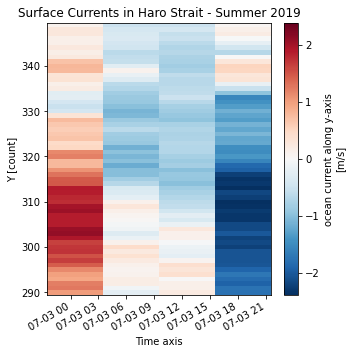

In [128]:
currents = sorted([p for p in current_path.glob('2019-07-02_VRaw_variables.nc')])
for file in currents:
    plt.figure(figsize = (5,5))
    current_data = xr.open_dataset(file)
    current_data.vVelocity[4:8, 0, 290:350, 238].plot(x="time")
    plt.title('Surface Currents in Haro Strait - Summer 2019')

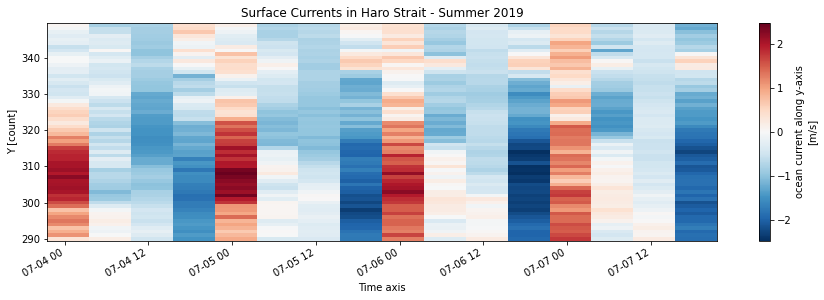

In [127]:
currents = sorted([p for p in current_path.glob('2020-07-04_VRaw_variables.nc')])
for file in currents:
    plt.figure(figsize = (15,4))
    current_data = xr.open_dataset(file)
    current_data.vVelocity[:, 0, 290:350, 238].plot(x="time")
    plt.title('Surface Currents in Haro Strait - Summer 2019')

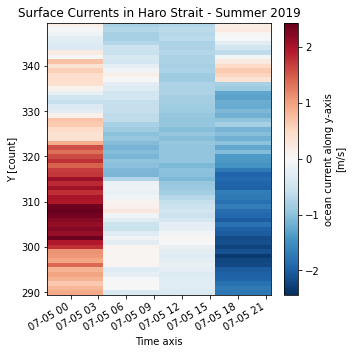

In [129]:
currents = sorted([p for p in current_path.glob('2020-07-04_VRaw_variables.nc')])
for file in currents:
    plt.figure(figsize = (5,5))
    current_data = xr.open_dataset(file)
    current_data.vVelocity[4:8, 0, 290:350, 238].plot(x="time")
    plt.title('Surface Currents in Haro Strait - Summer 2019')

Fall

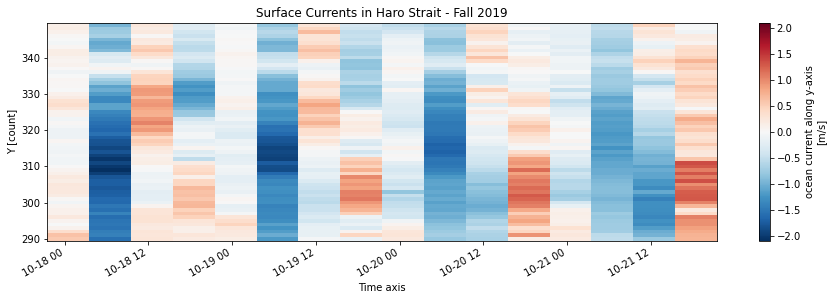

In [136]:
currents = sorted([p for p in current_path.glob('2019-10-18_VRaw_variables.nc')])
for file in currents:
    plt.figure(figsize = (15,4))
    current_data = xr.open_dataset(file)
    current_data.vVelocity[:, 0, 290:350, 238].plot(x="time")
    plt.title('Surface Currents in Haro Strait - Fall 2019')

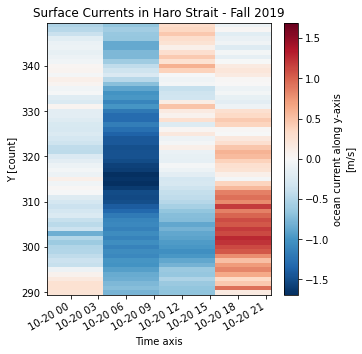

In [138]:
currents = sorted([p for p in current_path.glob('2019-10-18_VRaw_variables.nc')])
for file in currents:
    plt.figure(figsize = (5,5))
    current_data = xr.open_dataset(file)
    current_data.vVelocity[8:12, 0, 290:350, 238].plot(x="time")
    plt.title('Surface Currents in Haro Strait - Fall 2019')

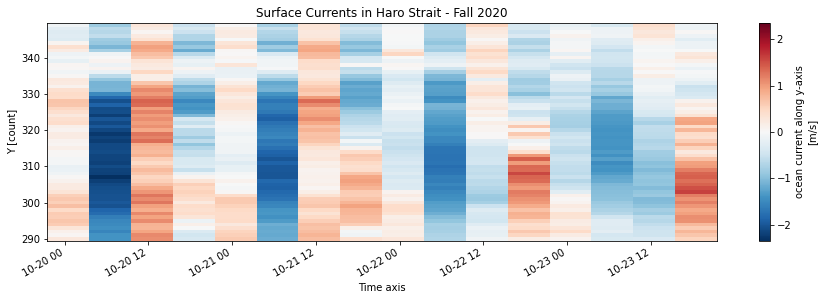

In [137]:
currents = sorted([p for p in current_path.glob('2020-10-20_VRaw_variables.nc')])
for file in currents:
    plt.figure(figsize = (15,4))
    current_data = xr.open_dataset(file)
    current_data.vVelocity[:, 0, 290:350, 238].plot(x="time")
    plt.title('Surface Currents in Haro Strait - Fall 2020')

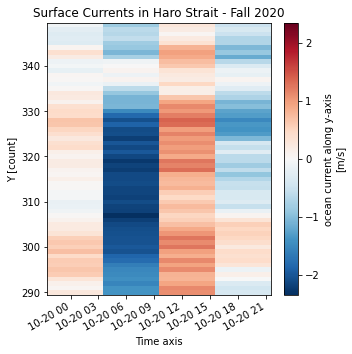

In [139]:
currents = sorted([p for p in current_path.glob('2020-10-20_VRaw_variables.nc')])
for file in currents:
    plt.figure(figsize = (5,5))
    current_data = xr.open_dataset(file)
    current_data.vVelocity[0:4, 0, 290:350, 238].plot(x="time")
    plt.title('Surface Currents in Haro Strait - Fall 2020')